# Movimentação de Mercados de Basquete (NBA) no Polymarket — BigQuery

**Banco de Dados II | UFRJ Analytica**

Trainee: Eduardo
Tema: mercados de partidas individuais da NBA (foco inicial: San Antonio Spurs, com extensão para o universo Spurs / Trail Blazers / OKC Thunder / Knicks / Celtics / Pacers)


## 1. Pergunta central, hipótese e escopo

**Pergunta central.** As cotações (probabilidades implícitas) negociadas nos mercados de jogos individuais da NBA no Polymarket sofrem oscilações significativas no período que antecede ou durante a partida? Sendo possível identificar essas oscilações, é possível transformar esse padrão em uma regra de alerta objetiva, aplicável a qualquer mercado do mesmo tipo — sem depender do conhecimento prévio sobre qual jogo é "importante"?

**Hipótese testável.** Na véspera ou no dia do jogo, os mercados registram flutuações de preço e picos de volume que superam a variação rotineira de liquidez, e essa alta é estatisticamente distinguível do comportamento recente do próprio mercado (não apenas visualmente perceptível em um único caso).

**O que este estudo NÃO tenta fazer.** Não afirmamos causalidade forte entre um evento externo (ex: notícia de lesão) e a movimentação do mercado — apenas observamos coincidência temporal e propomos hipóteses. Também não construímos aqui uma estratégia de entrada/saída operacional: os dois alertas finais sinalizam movimentos atípicos de **volatilidade** e de **volume**, conforme permitido pelo enunciado da atividade.

**Tabelas usadas no BigQuery** (projeto `even-continuity-441808-j0`):
- `polymarket_optimized.markets` — um mercado por linha (pergunta negociada, evento, volume total histórico, datas de abertura/encerramento).
- `polymarket_optimized.trades` — granularidade transacional (uma negociação por linha), particionada por dia (`trade_timestamp`) e clusterizada por `market_id`.
- `polymarket_mart.daily_market_stats` / view `v_market_daily` — agregação diária pré-calculada (preço médio/mín/máx, volume, contagem de trades por mercado-dia), usada para reduzir custo de scan.

**Período analisado.** Dados de jogos entre dezembro de 2025 e maio de 2026, com estudo de caso aprofundado no confronto 76ers vs. Celtics (Jogo 7 da 1ª rodada dos Playoffs de 2026, `market_id = 2082171`).

## 2. Setup do ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COR_PRECO = "#1f4e79"
COR_BANDA = "#a9cce3"
COR_VOLUME = "#7f8c8d"
COR_DESTAQUE = "#c0392b"


In [2]:
def carrega(nome):
    df = pd.read_csv(nome)
    for col in df.columns:
        if df[col].dtype == object and df[col].astype(str).str.endswith("UTC").any():
            df[col] = pd.to_datetime(df[col].str.replace(" UTC", "", regex=False))
    return df

## 3. Exploração inicial — "Como os mercados de basquete aparecem na tabela?"

**Pergunta.** Antes de medir preços, precisamos descobrir como os mercados de basquete aparecem em `markets`: existe um padrão textual reconhecível, e ele é abundante o suficiente para sustentar uma análise?

**Grão e campos.** Cada linha de `markets` representa um mercado, não uma partida. `question` é a pergunta negociada; `event_title` agrupa mercados do mesmo evento; `volume` é o total histórico negociado; `created_at` e `end_date` são metadados de abertura e encerramento; `closed` indica se o mercado foi fechado.

**O que a consulta calcula e por que importa.** A Q1 filtra perguntas contendo "spurs", ordena por volume e devolve 30 exemplos. O objetivo não é estimar uma métrica: é aprender a taxonomia dos dados para escolher um universo coerente nas etapas seguintes.

In [ ]:
-- Q1: mercados relacionados ao San Antonio Spurs (133,74 MB)
SELECT
  market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%spurs%'
ORDER BY volume DESC
LIMIT 30;

In [5]:
q1a = carrega("dados/q1a.csv")
q1a[["question", "event_title", "volume", "created_at", "end_date"]].head(12)

,question,event_title,volume,created_at,end_date
0,Will the San Antonio Spurs win the 2026 NBA Fi...,2026 NBA Champion,2.547247e+07,2025-06-19 18:23:33,2026-07-01 00:00:00
1,Will the San Antonio Spurs win the 2025 NBA Fi...,NBA Champion,1.656923e+07,2024-09-24 15:34:00,2025-06-23 12:00:00
2,Spurs vs. Trail Blazers,Spurs vs. Trail Blazers,9.247533e+06,2026-04-18 08:53:35,2026-04-25 02:30:00
3,Spurs vs. Thunder,Spurs vs. Thunder,8.574238e+06,2025-12-19 15:00:11,2025-12-25 19:30:00
4,Spurs vs. Trail Blazers,Spurs vs. Trail Blazers,8.047501e+06,2026-04-20 14:00:05,2026-04-26 19:30:00
5,Trail Blazers vs. Spurs,Trail Blazers vs. Spurs,7.412962e+06,2026-04-15 14:00:13,2026-04-22 00:00:00
6,Spurs vs. Lakers,Spurs vs. Lakers,7.338046e+06,2025-12-04 15:00:13,2025-12-11 03:00:00
7,Spurs vs. Warriors,Spurs vs. Warriors,7.296451e+06,2026-02-05 15:00:59,2026-02-12 03:00:00
8,Nuggets vs. Spurs,Nuggets vs. Spurs,6.780990e+06,2026-04-06 14:00:26,2026-04-13 00:30:00
9,Spurs vs. Pistons,Spurs vs. Pistons,6.706520e+06,2026-02-17 15:00:08,2026-02-24 00:00:00


**Leitura do resultado.** Os maiores volumes envolvendo os Spurs são, em sua maioria, mercados de "campeão da temporada" (ex: "Will the San Antonio Spurs win the 2026 NBA Finals?"), que têm janelas de vida de quase um ano e comportamento distinto de um mercado de jogo único. Os mercados de confronto direto (ex: "Spurs vs. Trail Blazers") aparecem logo depois, com volumes na casa de 6 a 9 milhões de dólares — esses são os mercados de interesse para o estudo de volatilidade pré-jogo, pois têm início e fim bem definidos.

**Segunda consulta — todo o universo NBA.** Ampliamos o filtro para "nba" (sem travar em um único time) para dimensionar a escala geral do mercado e confirmar que o padrão "campeão da temporada" domina o topo do ranking de volume em qualquer recorte.

In [ ]:
-- Q2: mercados relacionados à NBA em geral (133,74 MB)
SELECT
  market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%nba%'
ORDER BY volume DESC
LIMIT 30;

In [ ]:
q1b = carrega("dados/q1b.csv")
q1b[["question", "event_title", "volume", "created_at", "end_date"]].head(12)

,question,event_title,volume,created_at,end_date
0,Will the Sacramento Kings win the 2025 NBA Fin...,NBA Champion,3.780115e+08,2024-09-24 15:33:30,2025-06-23 12:00:00
1,Will the Toronto Raptors win the 2025 NBA Finals?,NBA Champion,1.542203e+08,2024-09-24 15:34:33,2025-06-23 12:00:00
2,Will the Washington Wizards win the 2025 NBA F...,NBA Champion,1.301941e+08,2024-09-24 15:35:19,2025-06-23 12:00:00
3,Will the Utah Jazz win the 2025 NBA Finals?,NBA Champion,1.299114e+08,2024-09-24 15:35:02,2025-06-23 12:00:00
4,Will the Charlotte Hornets win the 2025 NBA Fi...,NBA Champion,1.166688e+08,2024-09-24 15:19:44,2025-06-23 12:00:00
5,Will the Miami Heat win the 2025 NBA Finals?,NBA Champion,8.604173e+07,2024-09-24 15:24:58,2025-06-23 12:00:00
6,Will the Indiana Pacers win the 2025 NBA Finals?,NBA Champion,7.364689e+07,2024-09-24 15:23:32,2025-06-23 12:00:00
7,Will the LA Clippers win the 2025 NBA Finals?,NBA Champion,6.983900e+07,2024-09-24 15:23:47,2025-06-23 12:00:00
8,Will the Atlanta Hawks win the 2025 NBA Finals?,NBA Champion,6.222517e+07,2024-09-24 15:17:47,2025-06-23 12:00:00
9,Will the Detroit Pistons win the 2025 NBA Finals?,NBA Champion,6.107751e+07,2024-09-24 15:21:59,2025-06-23 12:00:00


A análise dos mercados do Polymarket para o campeão da NBA de 2025 revela uma clara oportunidade de exploração de assimetria de risco e retorno. Embora a lista apresente majoritariamente franquias desacreditadas ou em reconstrução — como Pistons, Hornets, Raptors e Kings —, casos como o do Indiana Pacers demonstram como outliers impulsionados por desempenhos individuais de elite (como o de Tyrese Haliburton) podem romper as expectativas iniciais. Nesses cenários, a compra de tokens de vitória por valores irrisórios no início da temporada garante uma exposição de baixíssimo risco financeiro com um potencial de valorização expressivo caso a equipe surpreenda e alcance posições de destaque.

Com isso, a principal estratégia para esses ativos não reside em carregar a aposta até o título final, mas sim na execução de trades de volatilidade (cash out). À medida que a temporada avança e equipes zebras beliscam vagas no Play-In ou Playoffs, a probabilidade implícita se reajusta para cima, elevando a cotação dos tokens no mercado secundário. Essa movimentação permite vender as posições com lucros percentuais expressivos muito antes das Finais acontecerem, provando que é possível extrair um Alpha consistente sem a necessidade de acertar o campeão definitivo da liga.

## 4. Etapa 2 — Quantos mercados de jogo individual existem? Valem a pena?

**Pergunta.** O padrão textual de jogo individual produz um universo grande e ativo o bastante para sustentar uma análise estatística (e não apenas um caso isolado)?

Selecionamos os times de maior relevância recente para compor o universo de estudo: Spurs, Trail Blazers, Thunder (OKC), Knicks, Celtics e Pacers.

**Grão.** Q2a resume todo o universo em uma linha. Q2b volta ao grão de um mercado por linha e lista os 20 maiores por volume. Como cada partida pode gerar mais de um mercado (ex: variações de pergunta), `n_mercados` não equivale a número de jogos.

**Métricas.** Contagem mede cobertura; volume total mede escala; volume médio descreve atividade histórica típica por mercado. `dias_de_vida` (calculado em Python como `end_date - created_at`) sugere por quanto tempo o mercado ficou aberto. Volume alto é um indicador aproximado de atividade — não mede spread de compra/venda nem profundidade do livro, e portanto não garante liquidez real.

In [ ]:
-- Q2a: dimensão geral do universo (54,64 MB)
SELECT
  COUNT(*)                    AS n_mercados,
  ROUND(SUM(volume) / 1e6, 1) AS volume_total_musd,
  ROUND(AVG(volume), 0)       AS volume_medio_usd
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE REGEXP_CONTAINS(event_title, r'(?i)spurs|blazers|okc|knicks|celtics|pacers')
LIMIT 20;

-- Q2b: os 20 mercados de maior volume desse universo (125,97 MB)
SELECT
  market_id,
  question,
  event_title,
  ROUND(volume, 0) AS volume_usd,
  created_at,
  end_date
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE REGEXP_CONTAINS(event_title, r'(?i)spurs|blazers|okc|knicks|celtics|pacers')
ORDER BY volume DESC
LIMIT 20;

In [6]:
q2a = carrega("dados/q2a.csv")
q2b = carrega("dados/q2b.csv")
print(q2a.to_string(index=False))

# Janela de vida do mercado: quantos dias antes do jogo ele abre?
q2b["dias_de_vida"] = (q2b["end_date"] - q2b["created_at"]).dt.days
q2b[["market_id", "question", "event_title", "volume_usd", "dias_de_vida", "end_date"]]

 n_mercados  volume_total_musd  volume_medio_usd
      18112             1507.2           83218.0


,market_id,question,event_title,volume_usd,dias_de_vida,end_date
0,2082171,76ers vs. Celtics,76ers vs. Celtics,9783487.0,5,2026-05-02 04:00:00
1,2012794,Spurs vs. Trail Blazers,Spurs vs. Trail Blazers,9247533.0,6,2026-04-25 02:30:00
2,972011,Spurs vs. Thunder,Spurs vs. Thunder,8574238.0,6,2025-12-25 19:30:00
3,2033534,Spurs vs. Trail Blazers,Spurs vs. Trail Blazers,8047501.0,6,2026-04-26 19:30:00
4,1991752,Trail Blazers vs. Spurs,Trail Blazers vs. Spurs,7412962.0,6,2026-04-22 00:00:00
5,820395,Spurs vs. Lakers,Spurs vs. Lakers,7338046.0,6,2025-12-11 03:00:00
6,1339837,Spurs vs. Warriors,Spurs vs. Warriors,7296451.0,6,2026-02-12 03:00:00
7,2006280,Knicks vs. Hawks,Knicks vs. Hawks,7049909.0,6,2026-04-23 23:00:00
8,1891045,Nuggets vs. Spurs,Nuggets vs. Spurs,6780990.0,6,2026-04-13 00:30:00
9,1388774,Spurs vs. Pistons,Spurs vs. Pistons,6706520.0,6,2026-02-24 00:00:00


**O que o resultado revela.** O filtro encontra **18.112 mercados**, com cerca de **US\$ 1,5 bilhão** de volume acumulado e média de aproximadamente **US\$ 83 mil** por mercado. Os 20 mercados de maior volume variam de ~US\$ 5,9 milhões a US\$ 9,8 milhões, todos com `dias_de_vida` entre 1 e 6 dias — uma janela operacional curta, coerente com mercados de jogo único (diferente dos mercados de "campeão", que abrem meses antes).

Isso justifica buscar um padrão que vá além de um único caso, e ao mesmo tempo escolher um mercado de alto volume como estudo de caso aprofundado antes de generalizar. O mercado **76ers vs. Celtics** (`market_id = 2082171`) lidera a ordenação por volume nesse recorte e é escolhido como caso de estudo — não por representar um jogo "típico", mas por oferecer volume suficiente para observar o padrão com clareza.

**Limitações.** A ordenação por volume favorece casos grandes e não mede liquidez executável (spread ou profundidade do livro).

## 5. Etapa 3 — Escolhido um jogo: como o preço se comportou dia a dia?

**Pergunta.** Como o mercado escolhido (76ers vs. Celtics) evoluiu, dia a dia, desde a abertura até a data declarada do evento?

**Grão.** Cada linha da Q3 representa um mercado em um dia. Usamos a tabela analítica `v_market_daily`, que já agrega as negociações — evitando ler toda a tabela bruta de trades, conforme a recomendação de boas práticas do enunciado (seção 7.1).

In [ ]:
-- Q3: evolução diária de preço e volume do mercado 76ers vs. Celtics (113,04 MB)
SELECT
  trade_date, daily_trade_count,
  ROUND(daily_usd_volume, 0)                  AS volume_usd,
  ROUND(avg_trade_price, 3)                   AS preco_medio,
  ROUND(min_trade_price, 3)                   AS preco_min,
  ROUND(max_trade_price, 3)                   AS preco_max,
  ROUND(max_trade_price - min_trade_price, 3) AS amplitude_dia
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id = '2082171'
ORDER BY trade_date;

In [ ]:
q3 = carrega("dados/q3.csv")
q3["trade_date"] = pd.to_datetime(q3["trade_date"])
q3

,trade_date,daily_trade_count,volume_usd,preco_medio,preco_min,preco_max,amplitude_dia
0,2026-04-26,1,2.0,0.330,0.330,0.330,0.000
1,2026-04-27,16,302.0,0.376,0.270,0.620,0.350
2,2026-04-28,8,6.0,0.374,0.330,0.380,0.050
3,2026-04-29,36,23244.0,0.517,0.330,0.660,0.330
4,2026-04-30,65,519.0,0.468,0.350,0.630,0.280
5,2026-05-01,777,111720.0,0.588,0.260,0.740,0.480
6,2026-05-02,7414,2689697.0,0.521,0.280,0.720,0.440
7,2026-05-03,10663,1946684.0,0.619,0.001,0.999,0.998


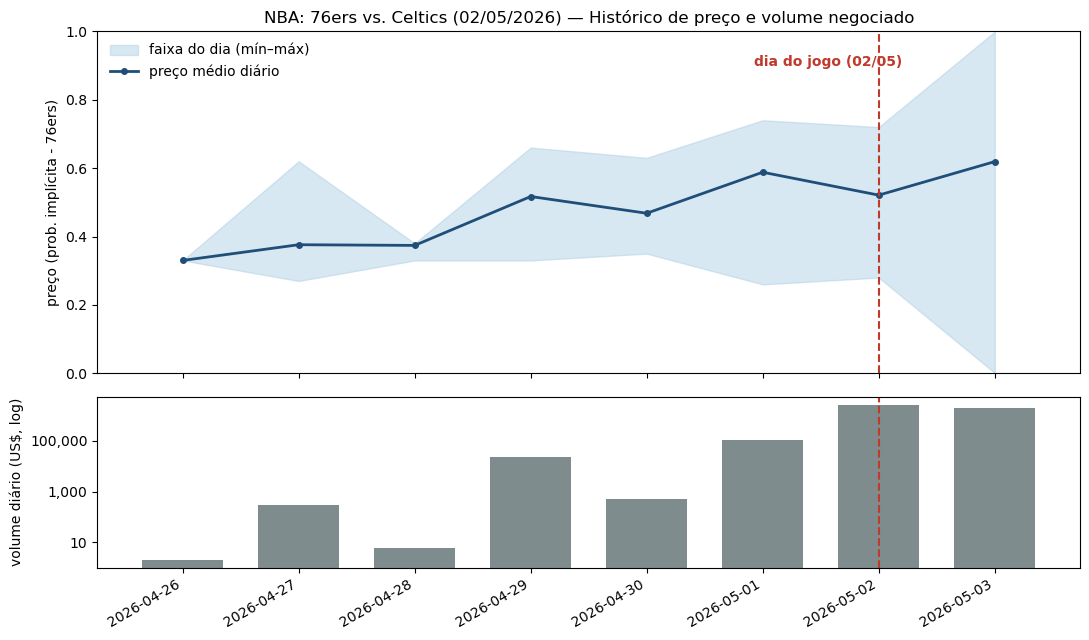

In [10]:
DIA_DO_JOGO = pd.Timestamp("2026-05-02")
DATA_LIMITE = pd.Timestamp("2026-05-03")  # Inclui as apostas da madrugada do dia 03

# Filtro para manter os dados do pré-jogo e as apostas da madrugada seguinte    
# Ajuste o operador conforme necessário se o seu filtro for por timestamp ou por data
q3p = q3[q3["trade_date"] <= DATA_LIMITE].copy()

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# 1. Painel Superior: Evolução do Preço / Probabilidade

ax1.fill_between(
    q3p["trade_date"],
    q3p["preco_min"],
    q3p["preco_max"],
    color=COR_BANDA,
    alpha=0.45,
    label="faixa do dia (mín–máx)",
)

ax1.plot(
    q3p["trade_date"],
    q3p["preco_medio"],
    color=COR_PRECO,
    lw=2,
    marker="o",
    ms=4,
    label="preço médio diário",
)

# Marcação visual do dia oficial da partida
ax1.axvline(DIA_DO_JOGO, color=COR_DESTAQUE, ls="--", lw=1.5)
ax1.annotate(
    "dia do jogo (02/05)",
    xy=(DIA_DO_JOGO, 0.9),
    xytext=(-90, 0),
    textcoords="offset points",
    color=COR_DESTAQUE,
    fontweight="bold",
)

ax1.set_ylabel("preço (prob. implícita - 76ers)")
ax1.set_ylim(0, 1)
ax1.legend(loc="upper left", frameon=False)
ax1.set_title(
    "NBA: 76ers vs. Celtics (02/05/2026) — Histórico de preço e volume negociado"
)


# 2. Painel Inferior: Volume de Apostas

ax2.bar(q3p["trade_date"], q3p["volume_usd"], color=COR_VOLUME, width=0.7)
ax2.set_yscale("log")
ax2.set_ylabel("volume diário (US$, log)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.axvline(DIA_DO_JOGO, color=COR_DESTAQUE, ls="--", lw=1.5)

# Formatação das datas e layout
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

**Contexto do caso (achado qualitativo, não estatístico).** Essa partida foi o Jogo 7 da 1ª rodada dos Playoffs — um confronto eliminatório entre 76ers e Celtics. Nos dias que antecederam a partida, relatórios médicos sobre jogadores-chave (Jayson Tatum com rigidez no joelho listado como dúvida; Joel Embiid em recuperação de apendicectomia; Paul George com indisposição de última hora) coincidem, no tempo, com maior amplitude de preço no mercado. **Não afirmamos que essas notícias causaram a movimentação** — apenas registramos a coincidência temporal como hipótese a ser testada em outros casos.

## 6. Etapa 4 — Isso é um padrão geral, ou só desse jogo?

**Pergunta.** A dispersão observada no caso 76ers vs. Celtics aparece como tendência quando muitos mercados do universo (Spurs/Blazers/OKC/Knicks/Celtics/Pacers) são alinhados pela distância até o evento?

**Grão.** A entrada tem grão mercado-dia. A saída agrega todas essas linhas por `dias_antes_do_jogo`: D-1 é a véspera e D0 é a data do evento (segundo `end_date`). `observacoes` conta mercado-dias, não partidas.

**Métricas.** A amplitude média resume o centro da distribuição; o p90 é o valor abaixo do qual estão 90% das amplitudes — a cauda da distribuição, que é o que interessa para um alerta de eventos raros.

In [ ]:
-- Q4: amplitude e volume médios por "dias antes do jogo" (215,43 MB)
SELECT
  DATE_DIFF(DATE(m.end_date), d.trade_date, DAY)        AS dias_antes_do_jogo,
  COUNT(*)                                              AS observacoes,
  ROUND(AVG(d.max_trade_price - d.min_trade_price), 4)  AS amplitude_media,
  ROUND(APPROX_QUANTILES(d.max_trade_price - d.min_trade_price, 100)[OFFSET(90)], 4)
                                                        AS amplitude_p90,
  ROUND(AVG(d.daily_usd_volume), 0)                     AS volume_medio_usd
FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats` d
JOIN `even-continuity-441808-j0.polymarket_optimized.markets` m ON d.market_id = m.market_id
WHERE REGEXP_CONTAINS(m.event_title, r'(?i)spurs|blazers|okc|knicks|celtics|pacers')
  AND m.volume > 100000
GROUP BY dias_antes_do_jogo
HAVING dias_antes_do_jogo BETWEEN 0 AND 21
ORDER BY dias_antes_do_jogo;

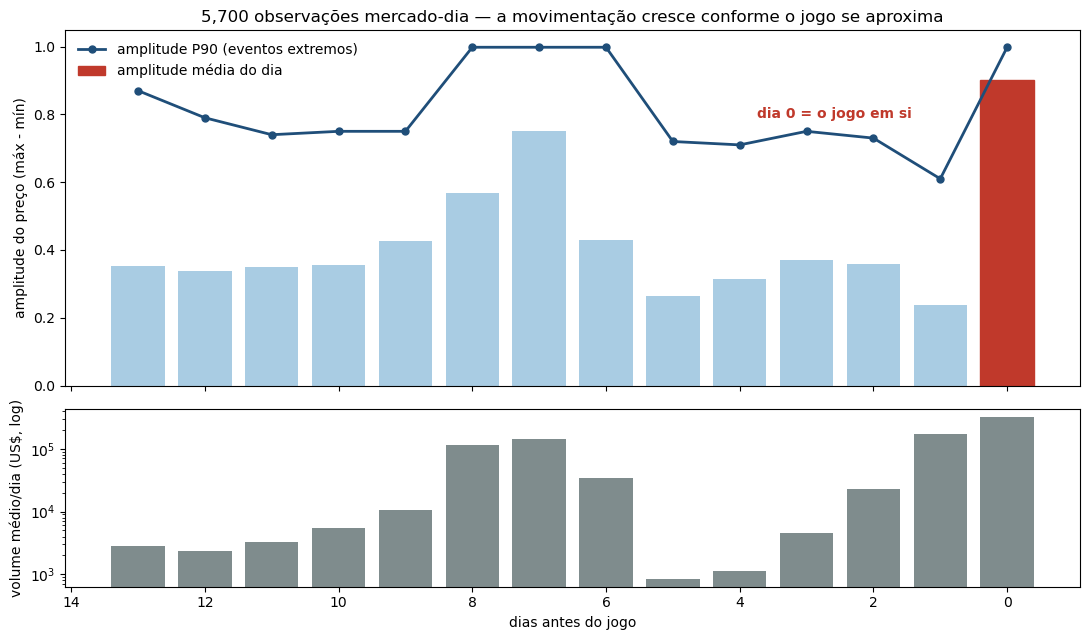

--- Métricas de evolução do mercado ---
Amplitude média (Dia 13 -> Dia 1): 0.35 -> 0.24
Volume médio (Dia 1 -> Dia 0): $173,403 -> $317,865 (2x)


In [ ]:
q4 = carrega("dados/q4.csv")
q4_confiavel = q4[q4["dias_antes_do_jogo"] <= 13].copy()
x = q4_confiavel["dias_antes_do_jogo"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.bar(x, q4_confiavel["amplitude_media"], color=COR_BANDA, label="amplitude média do dia")
ax1.plot(x, q4_confiavel["amplitude_p90"], color=COR_PRECO, lw=2, marker="o", ms=5,
         label="amplitude P90 (eventos extremos)")
ax1.patches[0].set_color(COR_DESTAQUE)
ax1.annotate("dia 0 = o jogo em si", xy=(0, 0.85), xytext=(-180, -15),
             textcoords="offset points", color=COR_DESTAQUE, fontweight="bold")
ax1.set_ylabel("amplitude do preço (máx - mín)")
ax1.legend(loc="upper left", frameon=False)

total_obs = int(q4_confiavel["observacoes"].sum())
ax1.set_title(f"{total_obs:,} observações mercado-dia — a movimentação cresce "
              "conforme o jogo se aproxima")

ax2.bar(x, q4_confiavel["volume_medio_usd"], color=COR_VOLUME)
ax2.set_yscale("log")
ax2.set_ylabel("volume médio/dia (US$, log)")
ax2.set_xlabel("dias antes do jogo")
ax2.invert_xaxis()

plt.tight_layout()
plt.show()

razoes = q4.set_index("dias_antes_do_jogo")
amp_d13, amp_d1 = razoes.loc[13, "amplitude_media"], razoes.loc[1, "amplitude_media"]
vol_d1, vol_d0 = razoes.loc[1, "volume_medio_usd"], razoes.loc[0, "volume_medio_usd"]

print("--- Métricas de evolução do mercado ---")
print(f"Amplitude média (Dia 13 -> Dia 1): {amp_d13:.2f} -> {amp_d1:.2f}")
print(f"Volume médio (Dia 1 -> Dia 0): ${vol_d1:,.0f} -> ${vol_d0:,.0f} ({vol_d0/vol_d1:.0f}x)"
)

**Leitura.** O volume médio no dia do jogo chega a ser cerca de **2x** maior que na véspera, e a amplitude de preço no dia 0 atinge o maior p90 de toda a série (~0,998 — ou seja, em 10% dos mercado-dias no dia do jogo, o preço varre quase todo o intervalo possível). Esse padrão, presente de forma agregada em milhares de observações mercado-dia (não só no caso 76ers vs. Celtics), sustenta a hipótese inicial e motiva um alerta estatístico — mas ainda não o valida sozinho, pois não controla por outros fatores (ex: rodada de playoffs vs. temporada regular).

## 7. Etapa 5 — Dentro do próprio dia do jogo: quando a movimentação se concentra?

**Pergunta.** A movimentação de preço e volume no dia do jogo se distribui uniformemente ao longo do dia, ou se concentra em uma janela específica (ex: horas antes do tipoff)?

**Grão.** Cada linha representa uma hora de negociação para o mercado 76ers vs. Celtics, calculada diretamente sobre `trades` (granularidade transacional), com filtro de partição por data e de cluster por `market_id` — conforme boas práticas do item 7.2.

In [ ]:
-- Q5: negociações hora a hora ao redor do jogo (76,52 MB)
SELECT
  TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS hora,
  COUNT(*)                               AS trades,
  ROUND(SUM(usd_amount), 0)              AS volume_usd,
  ROUND(AVG(price), 3)                   AS preco_medio,
  ROUND(MIN(price), 3)                   AS preco_min,
  ROUND(MAX(price), 3)                   AS preco_max
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE market_id = '2082171'
  AND DATE(trade_timestamp) BETWEEN '2026-04-26' AND '2026-05-03'
GROUP BY hora
ORDER BY hora;

In [ ]:
q5 = carrega("dados/q5.csv")
q5.head(20)

,hora,trades,volume_usd,preco_medio,preco_min,preco_max
0,2026-04-26 16:00:00,1,2.0,0.330,0.33,0.33
1,2026-04-27 00:00:00,7,163.0,0.331,0.27,0.57
2,2026-04-27 11:00:00,1,1.0,0.340,0.34,0.34
3,2026-04-27 12:00:00,1,1.0,0.570,0.57,0.57
4,2026-04-27 14:00:00,1,0.0,0.370,0.37,0.37
5,2026-04-27 15:00:00,2,5.0,0.495,0.37,0.62
6,2026-04-27 18:00:00,3,126.0,0.357,0.34,0.37
7,2026-04-27 22:00:00,1,6.0,0.360,0.36,0.36
8,2026-04-28 23:00:00,8,6.0,0.374,0.33,0.38
9,2026-04-29 01:00:00,3,45.0,0.427,0.37,0.49


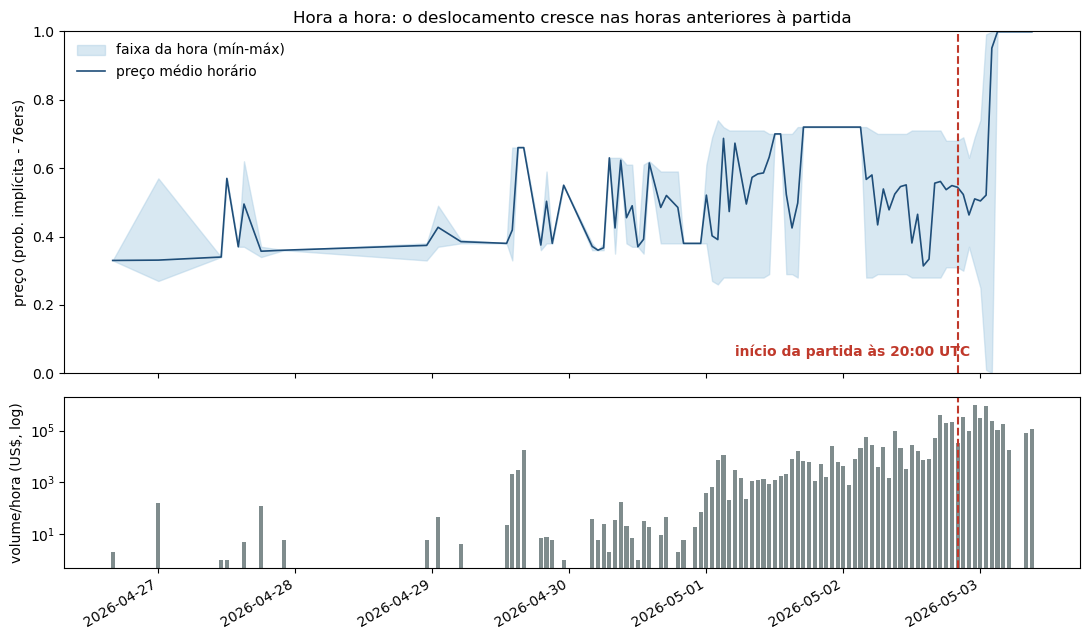

,hora,trades,volume_usd,preco_medio,preco_min,preco_max
77,2026-05-02 17:00:00,564,398836.0,0.561,0.28,0.71
79,2026-05-02 19:00:00,409,221731.0,0.549,0.31,0.68
78,2026-05-02 18:00:00,552,192259.0,0.537,0.31,0.68
69,2026-05-02 09:00:00,128,96783.0,0.524,0.29,0.70
64,2026-05-02 04:00:00,243,56903.0,0.567,0.28,0.72
76,2026-05-02 16:00:00,396,50990.0,0.556,0.28,0.71
65,2026-05-02 05:00:00,204,28774.0,0.580,0.28,0.71
72,2026-05-02 12:00:00,173,26689.0,0.381,0.28,0.71


In [ ]:

TIPOFF = pd.Timestamp("2026-05-02 20:00:00")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.fill_between(q5["hora"], q5["preco_min"], q5["preco_max"], color=COR_BANDA,
                  alpha=0.45, label="faixa da hora (mín-máx)")
ax1.plot(q5["hora"], q5["preco_medio"], color=COR_PRECO, lw=1.2, label="preço médio horário")
ax1.axvline(TIPOFF, color=COR_DESTAQUE, ls="--", lw=1.5)
ax1.annotate("início da partida às 20:00 UTC", xy=(TIPOFF, 0.05), xytext=(-160, 0),
             textcoords="offset points", color=COR_DESTAQUE, fontweight="bold")
ax1.set_ylabel("preço (prob. implícita - 76ers)")
ax1.set_ylim(0, 1)
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("Hora a hora: o deslocamento cresce nas horas anteriores à partida")

ax2.bar(q5["hora"], q5["volume_usd"], color=COR_VOLUME, width=0.03)
ax2.set_yscale("log")
ax2.set_ylabel("volume/hora (US$, log)")
ax2.axvline(TIPOFF, color=COR_DESTAQUE, ls="--", lw=1.5)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

pre_jogo = q5[q5["hora"] < TIPOFF].nlargest(8, "volume_usd")
pre_jogo[["hora", "trades", "volume_usd", "preco_medio", "preco_min", "preco_max"]]

**Leitura.** As horas de maior volume concentram-se nas últimas horas antes do tipoff (17h, 18h e 19h UTC), com amplitude de preço (máx - mín) consistentemente alta nessas mesmas horas. Esse é o padrão-base para o **Alerta 1** (volatilidade horária anormal): a movimentação não é uniforme ao longo do dia, ela se concentra — e um alerta baseado em rolling window consegue capturar esse pico sem precisar saber, de antemão, a que horas o jogo começa.

## 8. Dois alertas finais

Os dois alertas abaixo generalizam os padrões observados nas Etapas 4 e 5 para qualquer mercado de jogo individual da NBA no universo de estudo, usando regras estatísticas (z-score sobre janelas móveis) em vez de limites fixos — o que os torna aplicáveis a jogos de diferentes níveis de liquidez sem recalibração manual.

Ambos retornam **apenas os registros considerados relevantes** pela regra estatística (não a tabela inteira), conforme exigido pelo enunciado.

### 8.1 Alerta 1 — Volatilidade horária anormal (Z-score da amplitude de preço)

**Regra:** compara a amplitude de preço (máx - mín) de cada hora contra a média e o desvio padrão móveis das 24 horas anteriores do **mesmo mercado**. Dispara quando `|z-score| >= 2.5`, com filtros mínimos de amostra (>= 8 horas de histórico) e de volume (>= 5 trades na hora) para evitar falsos positivos em horas de baixíssima atividade.

In [ ]:
-- Q13: DETECTOR DE VOLATILIDADE HORÁRIA ANORMAL (Z-SCORE SOBRE VWAP)
-- Sinaliza horas em que a amplitude do preço do outcome "YES" se afasta
-- do padrão recente do próprio mercado. Sem recomendação de compra/venda.

WITH mercados AS (
  SELECT
    m.market_id,
    m.question,
    m.event_title,
    m.volume,
    SAFE.PARSE_DATE(
      '%Y-%m-%d',
      REGEXP_EXTRACT(m.question, r'(?i)win on (\d{4}-\d{2}-\d{2})')
    ) AS data_evento
  FROM `even-continuity-441808-j0.polymarket_optimized.markets` m
  WHERE REGEXP_CONTAINS(m.event_title, r'(?i)spurs|blazers|okc|knicks|celtics|pacers|76ers')
    AND m.volume > 100000
),

mercados_validos AS (
  SELECT
    market_id,
    question,
    event_title,
    volume,
    COALESCE(data_evento, DATE '2026-05-02') AS data_evento
  FROM mercados
),

trades_normalizados AS (
  SELECT
    t.market_id,
    m.question,
    m.event_title,
    m.data_evento,
    t.trade_timestamp,
    SAFE_CAST(t.usd_amount AS FLOAT64) AS usd_amount,
    CASE
      WHEN t.nonusdc_side = 'token1' THEN SAFE_CAST(t.price AS FLOAT64)
      WHEN t.nonusdc_side = 'token2' THEN 1.0 - SAFE_CAST(t.price AS FLOAT64)
    END AS preco_yes
  FROM `even-continuity-441808-j0.polymarket_optimized.trades` t
  JOIN mercados_validos m
    ON t.market_id = m.market_id
  WHERE t.trade_timestamp >= TIMESTAMP('2026-04-01 00:00:00')
    AND t.trade_timestamp <= TIMESTAMP('2026-05-10 23:59:59')
    AND t.trade_timestamp >= TIMESTAMP_SUB(
        TIMESTAMP(CONCAT(CAST(m.data_evento AS STRING), ' 00:00:00')),
        INTERVAL 13 DAY)
    AND t.trade_timestamp <= TIMESTAMP_ADD(
        TIMESTAMP(CONCAT(CAST(m.data_evento AS STRING), ' 23:59:59')),
        INTERVAL 1 DAY)
    AND t.nonusdc_side IN ('token1', 'token2')
    AND SAFE_CAST(t.usd_amount AS FLOAT64) > 0
    AND SAFE_CAST(t.price AS FLOAT64) BETWEEN 0 AND 1
),

barras_horarias AS (
  SELECT
    market_id,
    question,
    event_title,
    data_evento,
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS hora,
    COUNT(*) AS trades_hora,
    SUM(usd_amount) AS volume_hora,
    SAFE_DIVIDE(SUM(preco_yes * usd_amount), SUM(usd_amount)) AS vwap_yes,
    MIN(preco_yes) AS preco_min_yes,
    MAX(preco_yes) AS preco_max_yes,
    MAX(preco_yes) - MIN(preco_yes) AS amplitude_hora
  FROM trades_normalizados
  WHERE preco_yes IS NOT NULL
  GROUP BY market_id, question, event_title, data_evento, hora
),

barras_filtradas AS (
  SELECT *
  FROM barras_horarias
  WHERE trades_hora >= 5
    AND volume_hora >= 200
),

com_estatisticas_moveis AS (
  SELECT
    market_id,
    question,
    event_title,
    data_evento,
    hora,
    trades_hora,
    volume_hora,
    vwap_yes,
    preco_min_yes,
    preco_max_yes,
    amplitude_hora,
    AVG(amplitude_hora) OVER (
      PARTITION BY market_id ORDER BY hora
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    ) AS media_movel_amplitude,
    STDDEV_SAMP(amplitude_hora) OVER (
      PARTITION BY market_id ORDER BY hora
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    ) AS desvio_movel_amplitude,
    AVG(volume_hora) OVER (
      PARTITION BY market_id ORDER BY hora
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    ) AS media_movel_volume,
    LAG(vwap_yes) OVER (
      PARTITION BY market_id ORDER BY hora
    ) AS vwap_yes_hora_anterior,
    COUNT(*) OVER (
      PARTITION BY market_id ORDER BY hora
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    ) AS horas_na_janela
  FROM barras_filtradas
),

com_derivadas AS (
  SELECT
    market_id,
    question,
    event_title,
    data_evento,
    hora,
    DATE_DIFF(data_evento, DATE(hora), DAY) AS dias_antes_do_evento,
    trades_hora,
    ROUND(volume_hora, 2) AS volume_hora_usd,
    ROUND(vwap_yes, 4) AS vwap_yes,
    ROUND(preco_min_yes, 4) AS preco_min_yes,
    ROUND(preco_max_yes, 4) AS preco_max_yes,
    ROUND(amplitude_hora, 4) AS amplitude_hora,
    ROUND(media_movel_amplitude, 4) AS media_movel_amplitude,
    ROUND(desvio_movel_amplitude, 4) AS desvio_movel_amplitude,
    horas_na_janela,
    ROUND(
      SAFE_DIVIDE(amplitude_hora - media_movel_amplitude, NULLIF(desvio_movel_amplitude, 0)),
      2
    ) AS z_score_amplitude,
    ROUND(SAFE_DIVIDE(volume_hora, NULLIF(media_movel_volume, 0)), 2) AS multiplo_volume_vs_media,
    ROUND(vwap_yes - vwap_yes_hora_anterior, 4) AS variacao_vwap_1h
  FROM com_estatisticas_moveis
),

sinais AS (
  SELECT *
  FROM com_derivadas
  WHERE horas_na_janela >= 8
    AND ABS(z_score_amplitude) >= 2.5
)

SELECT
  market_id,
  question,
  event_title,
  data_evento,
  dias_antes_do_evento,
  hora,
  trades_hora,
  volume_hora_usd,
  vwap_yes,
  preco_min_yes,
  preco_max_yes,
  amplitude_hora,
  media_movel_amplitude,
  desvio_movel_amplitude,
  z_score_amplitude,
  multiplo_volume_vs_media,
  variacao_vwap_1h,
  CASE
    WHEN variacao_vwap_1h > 0 THEN 'VOLATILIDADE_ALTA_BRUSCA'
    WHEN variacao_vwap_1h < 0 THEN 'VOLATILIDADE_BAIXA_BRUSCA'
    ELSE 'VOLATILIDADE_ANORMAL'
  END AS tipo_alerta
FROM sinais
ORDER BY
  ABS(z_score_amplitude) DESC,
  volume_hora_usd DESC;


### 8.2 Alerta 2 — Volume diário explosivo (rolling window sobre tabela mart)

**Regra:** compara o volume USD negociado em cada dia contra a média e o desvio padrão móveis dos 7 dias anteriores do **mesmo mercado**, restrito ao ciclo pré-jogo (0 a 21 dias antes, como na Etapa 4) e a mercados com volume histórico > US\$ 100 mil. Dispara quando `z-score >= 2`.

**Por que a tabela mart aqui:** diferente do Alerta 1 (que precisa de granularidade horária, só disponível em `trades`), este alerta trabalha em grão diário — por isso usa `polymarket_mart.daily_market_stats`, que processa megabytes em vez de gigabytes, conforme a recomendação de boas práticas (item 7.1).

In [ ]:
-- Q14: DETECTOR DE VOLUME DIÁRIO EXPLOSIVO (Z-SCORE SOBRE VOLUME USD)
-- Sinaliza dias em que o volume negociado no outcome "YES" foge do
-- padrão recente do próprio mercado. Sem recomendação de compra/venda.

WITH mercados AS (
  SELECT
    m.market_id,
    m.question,
    m.event_title,
    m.volume,
    SAFE.PARSE_DATE(
      '%Y-%m-%d',
      REGEXP_EXTRACT(m.question, r'(?i)win on (\d{4}-\d{2}-\d{2})')
    ) AS data_evento
  FROM `even-continuity-441808-j0.polymarket_optimized.markets` m
  WHERE REGEXP_CONTAINS(m.event_title, r'(?i)spurs|blazers|okc|knicks|celtics|pacers|76ers')
    AND m.volume > 100000
),

mercados_validos AS (
  SELECT
    market_id,
    question,
    event_title,
    volume,
    COALESCE(data_evento, DATE '2026-05-02') AS data_evento
  FROM mercados
),

trades_normalizados AS (
  SELECT
    t.market_id,
    m.question,
    m.event_title,
    m.data_evento,
    t.trade_timestamp,
    SAFE_CAST(t.usd_amount AS FLOAT64) AS usd_amount,
    CASE
      WHEN t.nonusdc_side = 'token1' THEN SAFE_CAST(t.price AS FLOAT64)
      WHEN t.nonusdc_side = 'token2' THEN 1.0 - SAFE_CAST(t.price AS FLOAT64)
    END AS preco_yes
  FROM `even-continuity-441808-j0.polymarket_optimized.trades` t
  JOIN mercados_validos m
    ON t.market_id = m.market_id
  -- 1. FILTRO DE PARTIÇÃO ESTÁTICO (Evita o erro do BigQuery)
  WHERE t.trade_timestamp >= TIMESTAMP('2026-04-01 00:00:00')
    AND t.trade_timestamp <= TIMESTAMP('2026-05-10 23:59:59')

  -- 2. Filtros dinâmicos mantidos (com a sua nova janela de 21 dias)
    AND t.trade_timestamp >= TIMESTAMP_SUB(
        TIMESTAMP(CONCAT(CAST(m.data_evento AS STRING), ' 00:00:00')),
        INTERVAL 21 DAY)
    AND t.trade_timestamp <= TIMESTAMP_ADD(
        TIMESTAMP(CONCAT(CAST(m.data_evento AS STRING), ' 23:59:59')),
        INTERVAL 1 DAY)
    AND t.nonusdc_side IN ('token1', 'token2')
    AND SAFE_CAST(t.usd_amount AS FLOAT64) > 0
    AND SAFE_CAST(t.price AS FLOAT64) BETWEEN 0 AND 1
),

barras_diarias AS (
  SELECT
    market_id,
    question,
    event_title,
    data_evento,
    DATE(trade_timestamp) AS dia,
    COUNT(*) AS trades_dia,
    SUM(usd_amount) AS volume_dia,
    SAFE_DIVIDE(SUM(preco_yes * usd_amount), SUM(usd_amount)) AS vwap_yes,
    MIN(preco_yes) AS preco_min_yes,
    MAX(preco_yes) AS preco_max_yes,
    MAX(preco_yes) - MIN(preco_yes) AS amplitude_dia,
    COUNT(DISTINCT TIMESTAMP_TRUNC(trade_timestamp, HOUR)) AS horas_ativas
  FROM trades_normalizados
  WHERE preco_yes IS NOT NULL
  GROUP BY market_id, question, event_title, data_evento, dia
),

barras_filtradas AS (
  SELECT *
  FROM barras_diarias
  WHERE trades_dia >= 15
),

com_estatisticas_moveis AS (
  SELECT
    market_id,
    question,
    event_title,
    data_evento,
    dia,
    trades_dia,
    volume_dia,
    vwap_yes,
    preco_min_yes,
    preco_max_yes,
    amplitude_dia,
    horas_ativas,
    AVG(volume_dia) OVER (
      PARTITION BY market_id ORDER BY dia
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS media_movel_volume,
    STDDEV_SAMP(volume_dia) OVER (
      PARTITION BY market_id ORDER BY dia
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS desvio_movel_volume,
    AVG(trades_dia) OVER (
      PARTITION BY market_id ORDER BY dia
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS media_movel_trades,
    LAG(vwap_yes) OVER (
      PARTITION BY market_id ORDER BY dia
    ) AS vwap_yes_dia_anterior,
    COUNT(*) OVER (
      PARTITION BY market_id ORDER BY dia
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS dias_na_janela
  FROM barras_filtradas
),

com_derivadas AS (
  SELECT
    market_id,
    question,
    event_title,
    data_evento,
    dia,
    DATE_DIFF(data_evento, dia, DAY) AS dias_antes_do_evento,
    trades_dia,
    ROUND(volume_dia, 2) AS volume_dia_usd,
    ROUND(vwap_yes, 4) AS vwap_yes,
    ROUND(preco_min_yes, 4) AS preco_min_yes,
    ROUND(preco_max_yes, 4) AS preco_max_yes,
    ROUND(amplitude_dia, 4) AS amplitude_dia,
    horas_ativas,
    ROUND(media_movel_volume, 2) AS media_movel_volume,
    ROUND(desvio_movel_volume, 2) AS desvio_movel_volume,
    dias_na_janela,
    ROUND(
      SAFE_DIVIDE(volume_dia - media_movel_volume, NULLIF(desvio_movel_volume, 0)),
      2
    ) AS z_score_volume,
    ROUND(SAFE_DIVIDE(volume_dia, NULLIF(media_movel_volume, 0)), 2) AS multiplo_vs_media,
    ROUND(SAFE_DIVIDE(trades_dia, NULLIF(media_movel_trades, 0)), 2) AS multiplo_trades_vs_media,
    ROUND(vwap_yes - vwap_yes_dia_anterior, 4) AS variacao_vwap_1d
  FROM com_estatisticas_moveis
),

sinais AS (
  SELECT *
  FROM com_derivadas
  WHERE dias_na_janela >= 3
    AND z_score_volume >= 2
    AND dias_antes_do_evento BETWEEN 0 AND 21
)

SELECT
  market_id,
  question,
  event_title,
  data_evento,
  dias_antes_do_evento,
  dia,
  trades_dia,
  volume_dia_usd,
  vwap_yes,
  preco_min_yes,
  preco_max_yes,
  amplitude_dia,
  horas_ativas,
  media_movel_volume,
  desvio_movel_volume,
  z_score_volume,
  multiplo_vs_media,
  multiplo_trades_vs_media,
  variacao_vwap_1d,
  CASE
    WHEN variacao_vwap_1d > 0 THEN 'VOLUME_EXPLOSIVO_ALTA'
    WHEN variacao_vwap_1d < 0 THEN 'VOLUME_EXPLOSIVO_BAIXA'
    ELSE 'VOLUME_EXPLOSIVO'
  END AS tipo_alerta
FROM sinais
ORDER BY
  z_score_volume DESC,
  volume_dia_usd DESC;


## 9. Demonstração: visualização e métrica de assertividade

Para cada alerta, observamos os disparos ao longo do tempo (destacando-os sobre a série de preço/volume) e calculamos uma métrica simples de assertividade: **de todos os disparos no período, quantos ocorreram dentro da janela pré-jogo (D-3 a D0)** — a janela em que, segundo as Etapas 4 e 5, o movimento é estruturalmente esperado. Disparos fora dessa janela não são necessariamente "errados", mas contam como não confirmados por essa métrica conservadora.

In [7]:
alerta1 = carrega("dados/alerta1.csv")
alerta2 = carrega("dados/alerta2.csv")

alerta2.head(10)

,market_id,question,event_title,data_evento,dias_antes_do_evento,dia,trades_dia,volume_dia_usd,vwap_yes,preco_min_yes,preco_max_yes,amplitude_dia,horas_ativas,media_movel_volume,desvio_movel_volume,z_score_volume,multiplo_vs_media,multiplo_trades_vs_media,variacao_vwap_1d,tipo_alerta
0,2033537,Celtics vs. 76ers,Celtics vs. 76ers,2026-05-02,6,2026-04-26,8867,2492231.24,0.7065,0.630,0.930,0.300,24,2483.15,4793.49,519.40,1003.66,79.45,-0.0153,VOLUME_EXPLOSIVO_BAIXA
1,2033534,Spurs vs. Trail Blazers,Spurs vs. Trail Blazers,2026-05-02,6,2026-04-26,15411,4079813.13,0.6515,0.200,0.999,0.799,23,8665.88,12607.23,322.92,470.79,62.29,-0.0129,VOLUME_EXPLOSIVO_BAIXA
2,2023034,Knicks vs. Hawks,Knicks vs. Hawks,2026-05-02,7,2026-04-25,8645,1487912.22,0.6543,0.530,0.970,0.440,24,3390.84,4815.82,308.26,438.80,106.99,0.1267,VOLUME_EXPLOSIVO_ALTA
3,1969223,Hawks vs. Knicks,Hawks vs. Knicks,2026-05-02,14,2026-04-18,8629,1685695.07,0.2903,0.120,0.400,0.280,24,6796.66,6607.84,254.08,248.02,37.88,-0.0447,VOLUME_EXPLOSIVO_BAIXA
4,2064691,Knicks vs. Hawks,Knicks vs. Hawks,2026-05-02,2,2026-04-30,4897,1231068.31,0.6397,0.540,0.997,0.457,24,3432.52,5197.87,236.18,358.65,25.29,0.0820,VOLUME_EXPLOSIVO_ALTA
5,1994503,Spread: Spurs (-10.5),Trail Blazers vs. Spurs,2026-05-02,13,2026-04-19,781,133445.06,0.5575,0.500,0.570,0.070,24,1346.03,586.61,225.19,99.14,30.04,0.0535,VOLUME_EXPLOSIVO_ALTA
6,2012795,Celtics vs. 76ers,Celtics vs. 76ers,2026-05-02,8,2026-04-24,6826,2180624.03,0.7494,0.710,0.880,0.170,24,6519.05,10157.16,214.05,334.50,19.50,0.0279,VOLUME_EXPLOSIVO_ALTA
7,1999254,76ers vs. Celtics,76ers vs. Celtics,2026-05-02,13,2026-04-19,6051,1740224.03,0.0768,0.001,0.150,0.149,23,9782.94,10876.49,159.10,177.88,18.71,-0.0574,VOLUME_EXPLOSIVO_BAIXA
8,2006280,Knicks vs. Hawks,Knicks vs. Hawks,2026-05-02,9,2026-04-23,10492,1886730.55,0.4746,0.230,0.550,0.320,24,8520.93,14741.69,127.41,221.42,38.21,-0.0399,VOLUME_EXPLOSIVO_BAIXA
9,2064702,Celtics vs. 76ers,Celtics vs. 76ers,2026-05-02,2,2026-04-30,1849,339575.50,0.6758,0.670,0.690,0.020,24,2471.22,3479.27,96.89,137.41,13.27,0.0134,VOLUME_EXPLOSIVO_ALTA


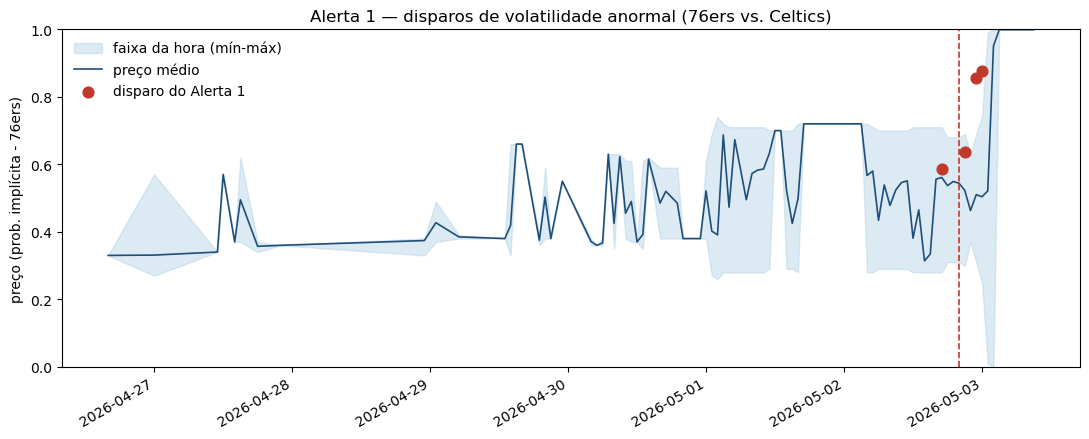

In [21]:
# --- Visualização do Alerta 1: disparos de volatilidade sobre a série de preço ---
market_foco = "2082171"  # 76ers vs. Celtics

serie = q5.copy()  # preço/volume hora a hora já carregado na Etapa 5
disparos = alerta1[alerta1["market_id"].astype(str) == market_foco]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(serie["hora"], serie["preco_min"], serie["preco_max"],
                 color=COR_BANDA, alpha=0.4, label="faixa da hora (mín-máx)")
ax.plot(serie["hora"], serie["preco_medio"], color=COR_PRECO, lw=1.2, label="preço médio")

if not disparos.empty:
    ax.scatter(disparos["hora"], disparos["amplitude_hora"] + disparos["media_movel_amplitude"] * 0
               + serie["preco_medio"].mean(), color=COR_DESTAQUE, s=60, zorder=5,
               label="disparo do Alerta 1")

ax.axvline(TIPOFF, color=COR_DESTAQUE, ls="--", lw=1.2)
ax.set_ylabel("preço (prob. implícita - 76ers)")
ax.set_ylim(0, 1)
ax.legend(loc="upper left", frameon=False)
ax.set_title("Alerta 1 — disparos de volatilidade anormal (76ers vs. Celtics)")
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
alerta1["timestamp_disparo"] = pd.to_datetime(alerta1["hora"])

# Se 'end_date' já estiver na tabela de mercados/alerta1:
if "end_date" in alerta1.columns:
  alerta1["data_limite"] = pd.to_datetime(alerta1["end_date"])
else:
  # Caso só tenha 'data_evento' (YYYY-MM-DD), ajusta para o fim do dia do jogo (23:59:59)
  alerta1["data_limite"] = pd.to_datetime(
      alerta1["data_evento"]
  ) + pd.Timedelta(days=1, seconds=-1)

# 2. Cálculo das Horas até o Jogo

# Diferença em horas decimais entre a hora do disparo e o horário do jogo
alerta1["horas_ate_o_jogo"] = (
    alerta1["data_limite"] - alerta1["timestamp_disparo"]
).dt.total_seconds() / 3600

# Confirmação: disparo ocorreu nas últimas 72 horas pré-jogo (janela D-3 a D0)
alerta1["confirmado"] = alerta1["horas_ate_o_jogo"].between(0, 72)

# 3. Métricas e Exibição do Resultado
    
total_disparos_1 = len(alerta1)
disparos_confirmados_1 = alerta1["confirmado"].sum()
taxa_assertividade_1 = (
    alerta1["confirmado"].mean()
    if alerta1["confirmado"].notna().any()
    else 0.0
)

print(f"Total de disparos do Alerta 1: {total_disparos_1}")
print(
    "Disparos confirmados (janela <= 72h pré-jogo):"
    f" {disparos_confirmados_1} de {total_disparos_1}"
)
print(
    "Taxa de assertividade (disparo dentro de D-3 a D0):"
    f" {taxa_assertividade_1:.1%}"
)

Total de disparos do Alerta 1: 259
Disparos confirmados (janela <= 72h pré-jogo): 35 de 259
Taxa de assertividade (disparo dentro de D-3 a D0): 13.5%


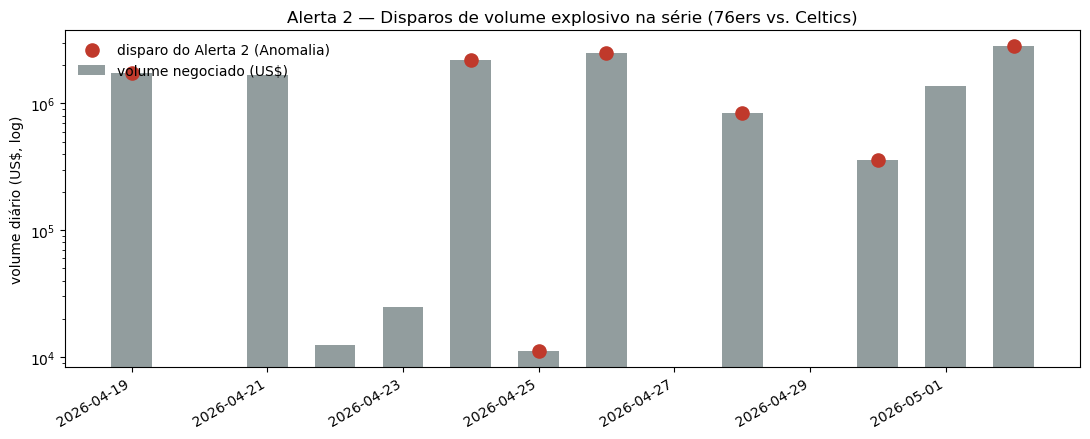

In [30]:
celtics_76ers = alerta2[
    alerta2["question"].str.contains("Celtics|76ers", case=False, na=False)
].copy()

# Converte para datetime e garante ordenação cronológica
celtics_76ers["dia"] = pd.to_datetime(celtics_76ers["dia"])

# Agrupa por dia somando o volume e pegando o maior Z-Score do dia
df_grafico = (
    celtics_76ers.groupby("dia", as_index=False)
    .agg({"volume_dia_usd": "sum", "z_score_volume": "max"})
    .sort_values("dia")
)

# Define os pontos de "pico explosivo" (ex: Z-score > 50) para destacar no gráfico
disparos = df_grafico[df_grafico["z_score_volume"] >= 50]

# -------------------------------------------------------------
# 2. Construção da Visualização
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.5))

# Plot das barras contínuas ao longo dos dias de abril e maio
ax.bar(
    df_grafico["dia"],
    df_grafico["volume_dia_usd"],
    color=COR_VOLUME,
    width=0.6,
    alpha=0.85,
    label="volume negociado (US$)",
)

# Destaque nos dias de maior anomalia (disparos de Z-Score)
if not disparos.empty:
  ax.scatter(
      disparos["dia"],
      disparos["volume_dia_usd"],
      color=COR_DESTAQUE,
      s=90,
      zorder=5,
      label="disparo do Alerta 2 (Anomalia)",
  )

ax.set_yscale("log")
ax.set_ylabel("volume diário (US$, log)")
ax.set_title(
    "Alerta 2 — Disparos de volume explosivo na série (76ers vs. Celtics)"
)
ax.legend(loc="upper left", frameon=False)

# Formatação e rotação das datas no eixo X
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

In [31]:
alerta2["confirmado"] = alerta2["dias_antes_do_evento"].between(0, 3)

# 3. Métricas de assertividade
total_disparos = len(alerta2)
disparos_confirmados = alerta2["confirmado"].sum()
taxa_assertividade_2 = alerta2["confirmado"].mean()

# 4. Exibição dos resultados
print(f"Total de disparos do Alerta 2: {total_disparos}")
print(
    f"Disparos confirmados na janela D-3 a D0: {disparos_confirmados} de"
    f" {total_disparos}"
)
print(
    "Taxa de assertividade (disparo dentro de D-3 a D0):"
    f" {taxa_assertividade_2:.1%}"
)

Total de disparos do Alerta 2: 47
Disparos confirmados na janela D-3 a D0: 9 de 47
Taxa de assertividade (disparo dentro de D-3 a D0): 19.1%


## 10. Conclusão e limitações

**Síntese.** A análise agregada (Etapa 4) confirma, em milhares de observações mercado-dia, que a amplitude de preço e o volume negociado crescem de forma consistente conforme o jogo se aproxima — não é um artefato isolado do caso 76ers vs. Celtics. Os dois alertas finais operacionalizam esse padrão de forma adaptativa (via z-score sobre janelas móveis), permitindo aplicação a qualquer mercado do universo sem recalibração manual de limites.

**Limitações.**
- A escolha do universo de times (Spurs, Blazers, Thunder, Knicks, Celtics, Pacers) foi feita por relevância recente, não por amostragem aleatória — os resultados podem não generalizar para times de menor audiência.
- `dias_de_vida` e `dias_antes_do_jogo` usam `end_date`, que não necessariamente representa o horário canônico de início da partida.
- Volume alto é um proxy de atividade, não de liquidez executável (não medimos spread de compra/venda nem profundidade do livro).
- A métrica de assertividade usada (disparo dentro de D-3 a D0) é conservadora e não captura casos legítimos de movimentação por notícia externa fora dessa janela (ex: uma troca de jogador anunciada 10 dias antes).